# Loan Approval Prediction Using Naive Bayes Classification

## Project Description

This project aims to predict whether a loan application will be approved or rejected using the **Naive Bayes** machine learning algorithm. The dataset contains applicant demographic information, financial details, and credit history. After preprocessing the data, the model is trained to classify loan applications as approved or rejected based on the applicant's characteristics. Finally, the model's performance is evaluated using various classification metrics.

---

## Import Libraries

In [9]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [5]:
df= pd.read_csv("loan_data.csv")

In [6]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
376,LP002953,Male,Yes,3+,Graduate,No,5703,0.0,128.0,360.0,1.0,Urban,Y
377,LP002974,Male,Yes,0,Graduate,No,3232,1950.0,108.0,360.0,1.0,Rural,Y
378,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
379,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    object 
 1   Gender             376 non-null    object 
 2   Married            381 non-null    object 
 3   Dependents         373 non-null    object 
 4   Education          381 non-null    object 
 5   Self_Employed      360 non-null    object 
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    object 
 12  Loan_Status        381 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 38.8+ KB


## Dataset Description

| Column Name | Data Type | Description |
|--------------|-----------|-------------|
| **Loan_ID** | Object | Unique identification number assigned to each loan application. |
| **Gender** | Object | Gender of the loan applicant (Male/Female). |
| **Married** | Object | Marital status of the applicant (Yes/No). |
| **Dependents** | Object | Number of dependents of the applicant (0, 1, 2, 3+). |
| **Education** | Object | Educational qualification of the applicant (Graduate/Not Graduate). |
| **Self_Employed** | Object | Indicates whether the applicant is self-employed (Yes/No). |
| **ApplicantIncome** | Integer | Monthly income earned by the primary applicant. |
| **CoapplicantIncome** | Float | Monthly income of the co-applicant. |
| **LoanAmount** | Float | Loan amount requested by the applicant (in thousands). |
| **Loan_Amount_Term** | Float | Repayment period of the loan in months. |
| **Credit_History** | Float | Applicant's credit history (1 = Good Credit History, 0 = Poor Credit History). |
| **Property_Area** | Object | Area where the property is located (Urban, Semiurban, Rural). |
| **Loan_Status** | Object | **Target Variable** indicating whether the loan application was Approved (Y) or Rejected (N). |

In [10]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,381.000000,381.000000,381.000000,370.000000,351.000000
mean,3579.845144,1277.275381,104.986877,340.864865,0.837607
std,1419.813818,2340.818114,28.358464,68.549257,0.369338
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2600.000000,0.000000,90.000000,360.000000,1.000000
50%,3333.000000,983.000000,110.000000,360.000000,1.000000
75%,4288.000000,2016.000000,127.000000,360.000000,1.000000
max,9703.000000,33837.000000,150.000000,480.000000,1.000000


In [11]:
df.describe(include='object')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,381,376,381,373,381,360,381,381
unique,381,2,2,4,2,2,3,2
top,LP001003,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,291,228,234,278,325,149,271


# Handling Null Values

In [8]:
df.isnull().sum()

Loan_ID               0
Gender                5
Married               0
Dependents            8
Education             0
Self_Employed        21
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     11
Credit_History       30
Property_Area         0
Loan_Status           0
dtype: int64

In [15]:
df['Gender'].value_counts()

Gender
Male      291
Female     85
Name: count, dtype: int64

In [12]:
df['Self_Employed'].value_counts()

Self_Employed
No     325
Yes     35
Name: count, dtype: int64

In [13]:
df['Loan_Amount_Term'].value_counts()

Loan_Amount_Term
360.0    312
180.0     29
480.0     11
300.0      7
120.0      3
84.0       3
240.0      2
60.0       1
12.0       1
36.0       1
Name: count, dtype: int64

In [14]:
df['Credit_History'].value_counts()

Credit_History
1.0    294
0.0     57
Name: count, dtype: int64

In [16]:
# Fill missing values with mode

df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)

df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)

df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)

df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

C:\Users\DeLL\AppData\Local\Temp\ipykernel_11788\1048480954.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
C:\Users\DeLL\AppData\Local\Temp\ipykernel_11788\1048480954.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.



In [17]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [18]:
df.duplicated().sum()

0

## Target Variable Analysis

In [19]:
df['Loan_Status'].value_counts()

Loan_Status
Y    271
N    110
Name: count, dtype: int64

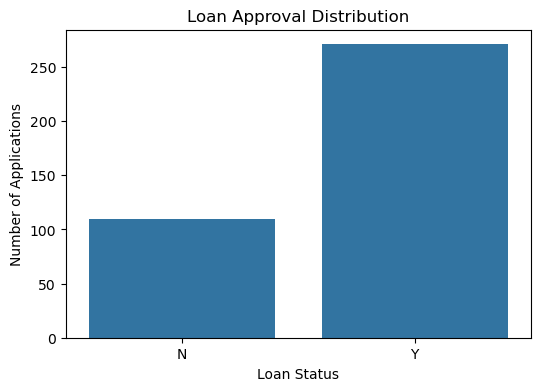

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Loan_Status'
)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")

plt.show()

# Feature Engineering

### Drop Unnecessary Column

In [21]:
df.drop('Loan_ID', axis=1, inplace=True)

In [22]:
df.head(3)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y


## Convert Categorical to numerical data

## Convert Credit_History float to integer

In [23]:
df['Credit_History'] = df['Credit_History'].astype(int)

In [24]:
df['Credit_History'].dtype


dtype('int32')

In [25]:
df['Credit_History'].value_counts()

Credit_History
1    324
0     57
Name: count, dtype: int64

## Label Encoding
* Gender
* Married
* Dependents
* Education
* Self_Employed
* Property_Area
* Loan_Status

In [28]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [29]:
cat_cols = df.select_dtypes(include='object').columns

cat_cols

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object')

In [30]:
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

In [31]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,1,1,0,0,4583,1508.0,128.0,360.0,1,0,0
1,1,1,0,0,1,3000,0.0,66.0,360.0,1,2,1
2,1,1,0,1,0,2583,2358.0,120.0,360.0,1,2,1
3,1,0,0,0,0,6000,0.0,141.0,360.0,1,2,1
4,1,1,0,1,0,2333,1516.0,95.0,360.0,1,2,1


In [32]:
df['Dependents'].value_counts()

Dependents
0    242
2     59
1     52
3     28
Name: count, dtype: int64

## Separate features and target

In [34]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Apply SMOTE to handle Imabalanced data 

In [37]:
from imblearn.over_sampling import SMOTE

In [38]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [39]:
y_train.value_counts()

Loan_Status
1    216
0     88
Name: count, dtype: int64

In [40]:
y_train_smote.value_counts()

Loan_Status
0    216
1    216
Name: count, dtype: int64

## Feature Scaling

In [41]:
from sklearn.preprocessing import StandardScaler

In [43]:
scaler = StandardScaler()
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

## Build Gaussian Naive Bayes Model

In [45]:
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()

## Train the Model

In [46]:
nb_model.fit(
    X_train_smote_scaled,
    y_train_smote
)

GaussianNB()

In [47]:
y_pred = nb_model.predict(
    X_test_scaled
)

## Model Evaluation

In [49]:
from sklearn.metrics import classification_report


print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.67      0.55      0.60        22
           1       0.83      0.89      0.86        55

    accuracy                           0.79        77
   macro avg       0.75      0.72      0.73        77
weighted avg       0.78      0.79      0.79        77



## Making the new prediction

In [50]:
new_customer = pd.DataFrame({
    'Gender': [1],
    'Married': [1],
    'Dependents': [0],
    'Education': [0],
    'Self_Employed': [0],
    'ApplicantIncome': [6000],
    'CoapplicantIncome': [2000],
    'LoanAmount': [150],
    'Loan_Amount_Term': [360],
    'Credit_History': [1],
    'Property_Area': [2]
})

In [53]:
new_customer_scaled = scaler.transform(new_customer)

prediction = nb_model.predict(new_customer_scaled)

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")

Loan Approved


### Get Prediction Probability

In [52]:
probability = nb_model.predict_proba(
    new_customer_scaled
)

probability

array([[0.01910161, 0.98089839]])